In [9]:
import pandas as pd
import glob
import numpy as np
from datetime import timedelta
from dateutil.relativedelta import relativedelta

# ================= CONFIG =================
FOLDER = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus"

MIN_ANALYSTS = 5
EXCLUDE_TICKERS = []  # e.g. ["YESBANK", "IDEA"]

# ================= HELPERS =================
def get_asof_past(dates, target_date):
    eligible = dates[dates <= target_date]
    return eligible.max() if not eligible.empty else None

def get_asof_future(dates, target_date):
    eligible = dates[dates >= target_date]
    return eligible.min() if not eligible.empty else None

def shift_back(date, weeks=0, months=0):
    d = date
    if weeks:
        d = d - timedelta(weeks=weeks)
    if months:
        d = d - relativedelta(months=months)
    return d

def shift_forward(date, weeks=0, months=0):
    d = date
    if weeks:
        d = d + timedelta(weeks=weeks)
    if months:
        d = d + relativedelta(months=months)
    return d

def safe_ratio(num, den):
    if pd.isna(num) or pd.isna(den) or den == 0:
        return np.nan
    return round(num / den - 1, 4)

# ================= LOAD ALL CSVs =================
files = sorted(glob.glob(f"{FOLDER}\\*_YahooConsensus.csv"))
if not files:
    raise FileNotFoundError("No *_YahooConsensus.csv files found in folder.")

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["Date"] = pd.to_datetime(df["Date"])
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Filter by analyst count
df_all = df_all[df_all["#Count"] >= MIN_ANALYSTS].copy()

# Sort
df_all.sort_values(["Date", "YAHOO Ticker", "FIN Yr"], inplace=True)
df_all.reset_index(drop=True, inplace=True)

# Unique dates
all_dates = pd.Series(sorted(df_all["Date"].unique()))
latest_date = all_dates.iloc[-1]
latest_date_str = latest_date.strftime("%Y%m%d")
output_file = f"{FOLDER}\\{latest_date_str}_YahooConsensus_FactorDataset.csv"

# Precompute price panel: (Date, Ticker) -> Price
price_panel = df_all.groupby(["Date", "YAHOO Ticker"])["Current Price"].first().unstack()

# Group by (Date, Ticker) for fundamentals
group_dt = df_all.groupby(["Date", "YAHOO Ticker"])

rows = []

# ================= MAIN LOOP =================
for current_date in all_dates:
    # All tickers on this date
    tickers_today = df_all.loc[df_all["Date"] == current_date, "YAHOO Ticker"].unique()

    # Precompute past and future dates for price/fwd returns
    p1w_date = get_asof_past(all_dates, shift_back(current_date, weeks=1))
    p2w_date = get_asof_past(all_dates, shift_back(current_date, weeks=2))
    p1m_date = get_asof_past(all_dates, shift_back(current_date, months=1))
    p3m_date = get_asof_past(all_dates, shift_back(current_date, months=3))

    f1w_date = get_asof_future(all_dates, shift_forward(current_date, weeks=1))
    f2w_date = get_asof_future(all_dates, shift_forward(current_date, weeks=2))
    f1m_date = get_asof_future(all_dates, shift_forward(current_date, months=1))
    f3m_date = get_asof_future(all_dates, shift_forward(current_date, months=3))

    for ticker in tickers_today:
        # ---------- CURRENT SNAPSHOT ----------
        try:
            df_curr = group_dt.get_group((current_date, ticker))
        except KeyError:
            continue

        # All FIN Yrs for this ticker on this date
        fin_years_curr = sorted(df_curr["FIN Yr"].unique())
        if len(fin_years_curr) == 0:
            continue

        # Determine Y1 and Y2 (earliest two FIN Yrs)
        Y1 = fin_years_curr[0]
        Y2 = fin_years_curr[1] if len(fin_years_curr) > 1 else None

        # Helper to get row for a given FIN Yr (if exists)
        def get_row_for_fy(df, fy):
            sub = df[df["FIN Yr"] == fy]
            if sub.empty:
                return None
            return sub.iloc[0]

        # Current rows for Y1/Y2
        row_y1_curr = get_row_for_fy(df_curr, Y1)
        row_y2_curr = get_row_for_fy(df_curr, Y2) if Y2 is not None else None

        # Use first row for TP, price, analyst count (same across FIN Yrs)
        base_row = df_curr.iloc[0]
        tp_min_curr = base_row["TP(Min)"]
        tp_avg_curr = base_row["TP(Avg)"]
        tp_max_curr = base_row["TP(Max)"]
        analyst_count = base_row["#Count"]

        # ---------- PAST 1W FUNDAMENTALS ----------
        past_1w_y1_rev_min_chg = np.nan
        past_1w_y1_rev_avg_chg = np.nan
        past_1w_y1_rev_max_chg = np.nan
        past_1w_y1_eps_min_chg = np.nan
        past_1w_y1_eps_avg_chg = np.nan
        past_1w_y1_eps_max_chg = np.nan

        past_1w_y2_rev_min_chg = np.nan
        past_1w_y2_rev_avg_chg = np.nan
        past_1w_y2_rev_max_chg = np.nan
        past_1w_y2_eps_min_chg = np.nan
        past_1w_y2_eps_avg_chg = np.nan
        past_1w_y2_eps_max_chg = np.nan

        past_1w_tp_min_chg = np.nan
        past_1w_tp_avg_chg = np.nan
        past_1w_tp_max_chg = np.nan

        if p1w_date is not None:
            try:
                df_past = group_dt.get_group((p1w_date, ticker))
            except KeyError:
                df_past = None

            if df_past is not None and not df_past.empty:
                # TP changes (no FIN Yr dependency)
                base_past = df_past.iloc[0]
                tp_min_past = base_past["TP(Min)"]
                tp_avg_past = base_past["TP(Avg)"]
                tp_max_past = base_past["TP(Max)"]

                past_1w_tp_min_chg = safe_ratio(tp_min_curr, tp_min_past)
                past_1w_tp_avg_chg = safe_ratio(tp_avg_curr, tp_avg_past)
                past_1w_tp_max_chg = safe_ratio(tp_max_curr, tp_max_past)

                # Past rows per FIN Yr
                row_y1_past = get_row_for_fy(df_past, Y1)
                row_y2_past = get_row_for_fy(df_past, Y2) if Y2 is not None else None

                # Y1 Rev/EPS changes (only if same FIN Yr exists in past)
                if row_y1_curr is not None and row_y1_past is not None:
                    past_1w_y1_rev_min_chg = safe_ratio(row_y1_curr["Rev.(Min)"], row_y1_past["Rev.(Min)"])
                    past_1w_y1_rev_avg_chg = safe_ratio(row_y1_curr["Rev.(Avg)"], row_y1_past["Rev.(Avg)"])
                    past_1w_y1_rev_max_chg = safe_ratio(row_y1_curr["Rev.(Max)"], row_y1_past["Rev.(Max)"])

                    past_1w_y1_eps_min_chg = safe_ratio(row_y1_curr["EPS(Min)"], row_y1_past["EPS(Min)"])
                    past_1w_y1_eps_avg_chg = safe_ratio(row_y1_curr["EPS(Avg)"], row_y1_past["EPS(Avg)"])
                    past_1w_y1_eps_max_chg = safe_ratio(row_y1_curr["EPS(Max)"], row_y1_past["EPS(Max)"])

                # Y2 Rev/EPS changes (only if Y2 exists and same FIN Yr exists in past)
                if Y2 is not None and row_y2_curr is not None and row_y2_past is not None:
                    past_1w_y2_rev_min_chg = safe_ratio(row_y2_curr["Rev.(Min)"], row_y2_past["Rev.(Min)"])
                    past_1w_y2_rev_avg_chg = safe_ratio(row_y2_curr["Rev.(Avg)"], row_y2_past["Rev.(Avg)"])
                    past_1w_y2_rev_max_chg = safe_ratio(row_y2_curr["Rev.(Max)"], row_y2_past["Rev.(Max)"])

                    past_1w_y2_eps_min_chg = safe_ratio(row_y2_curr["EPS(Min)"], row_y2_past["EPS(Min)"])
                    past_1w_y2_eps_avg_chg = safe_ratio(row_y2_curr["EPS(Avg)"], row_y2_past["EPS(Avg)"])
                    past_1w_y2_eps_max_chg = safe_ratio(row_y2_curr["EPS(Max)"], row_y2_past["EPS(Max)"])

        # ---------- PRICE CHANGES & FORWARD RETURNS ----------
        price_0 = price_panel.loc[current_date, ticker] if ticker in price_panel.columns else np.nan

        def get_price(date_obj):
            if date_obj is None:
                return np.nan
            if date_obj not in price_panel.index:
                return np.nan
            if ticker not in price_panel.columns:
                return np.nan
            return price_panel.loc[date_obj, ticker]

        price_p1w = get_price(p1w_date)
        price_p2w = get_price(p2w_date)
        price_p1m = get_price(p1m_date)
        price_p3m = get_price(p3m_date)

        price_f1w = get_price(f1w_date)
        price_f2w = get_price(f2w_date)
        price_f1m = get_price(f1m_date)
        price_f3m = get_price(f3m_date)

        past_1w_price_chg = safe_ratio(price_0, price_p1w)
        past_2w_price_chg = safe_ratio(price_0, price_p2w)
        past_1m_price_chg = safe_ratio(price_0, price_p1m)
        past_3m_price_chg = safe_ratio(price_0, price_p3m)

        fwd_1w_price_chg = safe_ratio(price_f1w, price_0)
        fwd_2w_price_chg = safe_ratio(price_f2w, price_0)
        fwd_1m_price_chg = safe_ratio(price_f1m, price_0)
        fwd_3m_price_chg = safe_ratio(price_f3m, price_0)

        # ---------- BUILD ROW ----------
        row = {
            "Date": current_date,
            "YAHOO Ticker": ticker,

            "Past_1W_TP_Min_Change": past_1w_tp_min_chg,
            "Past_1W_TP_Avg_Change": past_1w_tp_avg_chg,
            "Past_1W_TP_Max_Change": past_1w_tp_max_chg,

            "Past_1W_Y1_Rev_Min_Change": past_1w_y1_rev_min_chg,
            "Past_1W_Y1_Rev_Avg_Change": past_1w_y1_rev_avg_chg,
            "Past_1W_Y1_Rev_Max_Change": past_1w_y1_rev_max_chg,

            "Past_1W_Y2_Rev_Min_Change": past_1w_y2_rev_min_chg,
            "Past_1W_Y2_Rev_Avg_Change": past_1w_y2_rev_avg_chg,
            "Past_1W_Y2_Rev_Max_Change": past_1w_y2_rev_max_chg,

            "Past_1W_Y1_EPS_Min_Change": past_1w_y1_eps_min_chg,
            "Past_1W_Y1_EPS_Avg_Change": past_1w_y1_eps_avg_chg,
            "Past_1W_Y1_EPS_Max_Change": past_1w_y1_eps_max_chg,

            "Past_1W_Y2_EPS_Min_Change": past_1w_y2_eps_min_chg,
            "Past_1W_Y2_EPS_Avg_Change": past_1w_y2_eps_avg_chg,
            "Past_1W_Y2_EPS_Max_Change": past_1w_y2_eps_max_chg,

            "Past_1W_Price_Change": past_1w_price_chg,
            "Past_2W_Price_Change": past_2w_price_chg,
            "Past_1M_Price_Change": past_1m_price_chg,
            "Past_3M_Price_Change": past_3m_price_chg,

            "Fwd_1W_Price_Change": fwd_1w_price_chg,
            "Fwd_2W_Price_Change": fwd_2w_price_chg,
            "Fwd_1M_Price_Change": fwd_1m_price_chg,
            "Fwd_3M_Price_Change": fwd_3m_price_chg,

            "Analyst_Count_Latest": analyst_count,
        }

        rows.append(row)

# ================= BUILD FINAL DF =================
factor_df = pd.DataFrame(rows)

# Ensure uniqueness of (Date, Ticker)
dupes = factor_df.duplicated(subset=["Date", "YAHOO Ticker"])
if dupes.any():
    dup_list = factor_df.loc[dupes, ["Date", "YAHOO Ticker"]].drop_duplicates()
    print("WARNING: Duplicate (Date, Ticker) combinations found:")
    print(dup_list)
else:
    print("Verified: (Date, Ticker) is unique in factor dataset.")

# Apply ticker exclusion
if EXCLUDE_TICKERS:
    factor_df = factor_df[~factor_df["YAHOO Ticker"].isin(EXCLUDE_TICKERS)]

# Reorder columns: Date, Ticker, then signals
cols = ["Date", "YAHOO Ticker"] + [c for c in factor_df.columns if c not in ["Date", "YAHOO Ticker"]]
factor_df = factor_df[cols]

# Sort by Date, Ticker
factor_df.sort_values(["Date", "YAHOO Ticker"], inplace=True)
factor_df.reset_index(drop=True, inplace=True)

# Save ALL dates, filename uses latest date
factor_df.to_csv(output_file, index=False)

print(f"\nMulti-date factor dataset created:\n{output_file}")
print(f"Total rows: {len(factor_df)}, unique (Date, Ticker): {factor_df[['Date','YAHOO Ticker']].drop_duplicates().shape[0]}")

Verified: (Date, Ticker) is unique in factor dataset.

Multi-date factor dataset created:
C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus\20260213_YahooConsensus_FactorDataset.csv
Total rows: 1151, unique (Date, Ticker): 1151


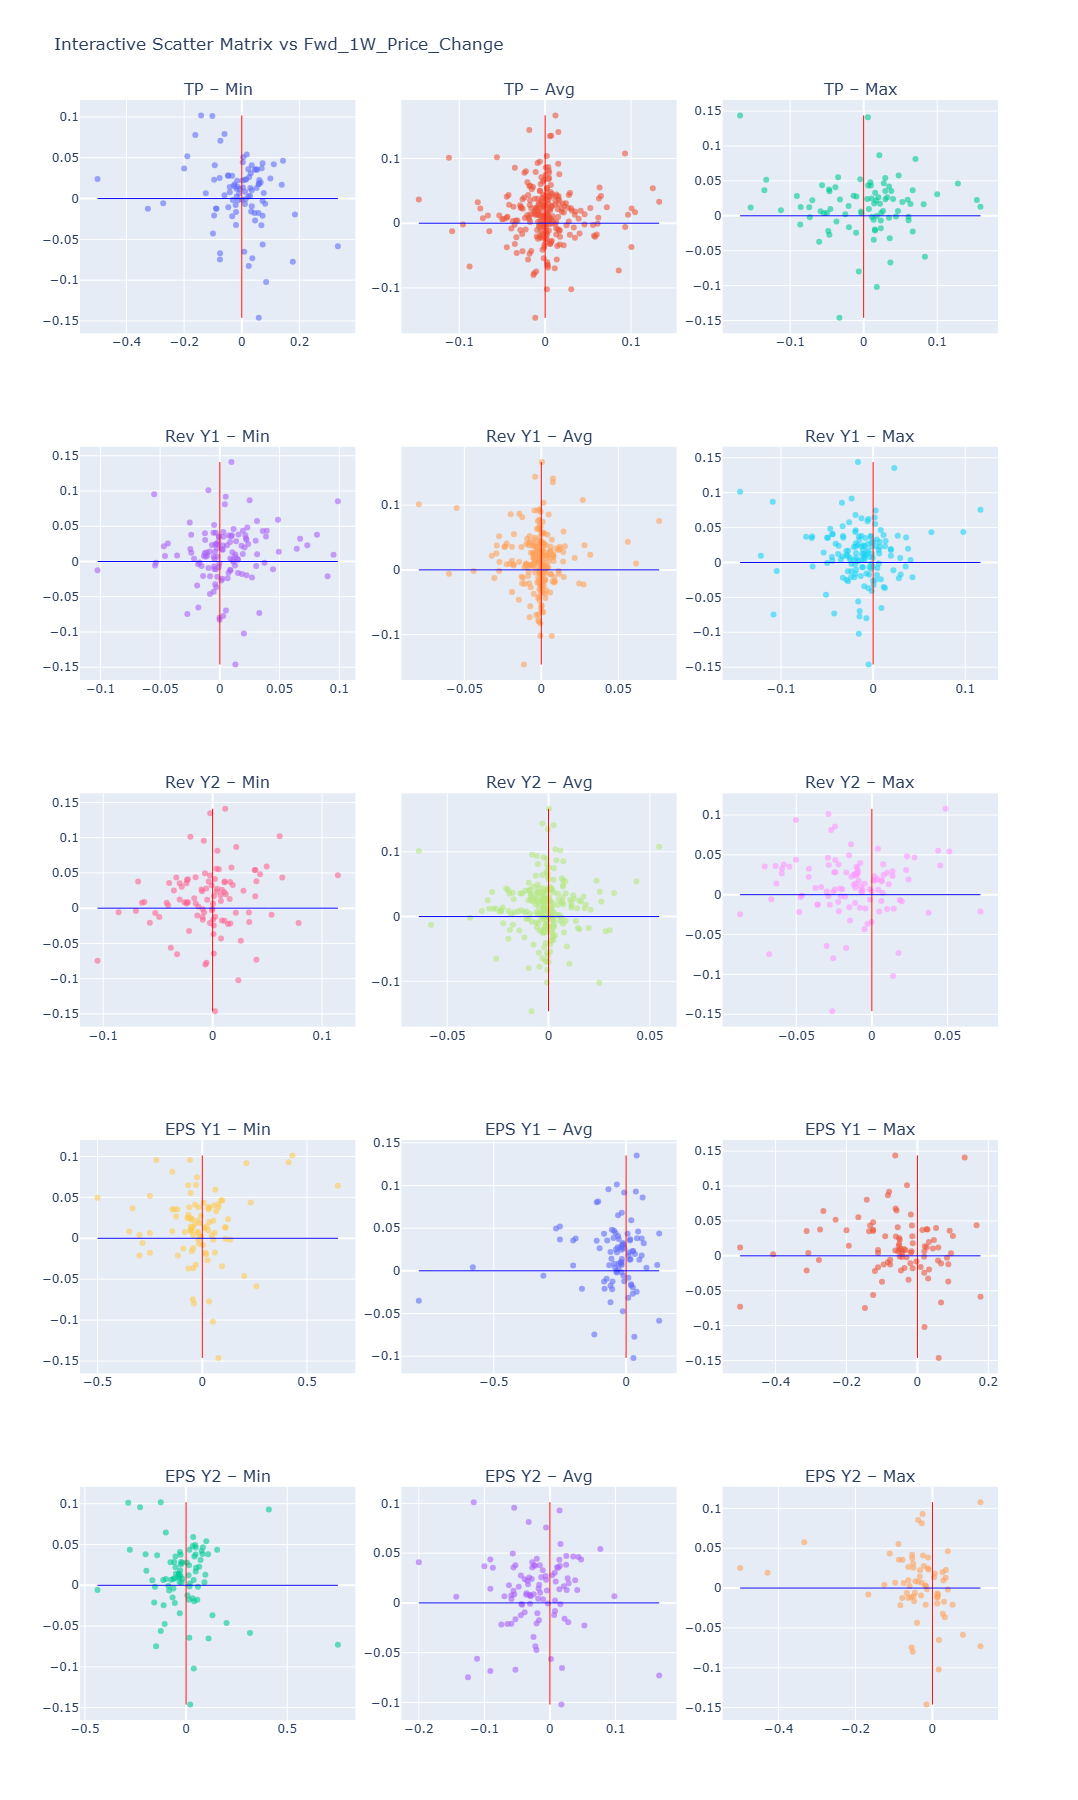

In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ================= LOAD FACTOR DATASET =================
file = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus\20260206_YahooConsensus_FactorDataset.csv"
df = pd.read_csv(file, parse_dates=["Date"])

# ================= FEATURE GROUPS =================
tp_features = [
    "Past_1W_TP_Min_Change",
    "Past_1W_TP_Avg_Change",
    "Past_1W_TP_Max_Change",
]

rev_y1_features = [
    "Past_1W_Y1_Rev_Min_Change",
    "Past_1W_Y1_Rev_Avg_Change",
    "Past_1W_Y1_Rev_Max_Change",
]

rev_y2_features = [
    "Past_1W_Y2_Rev_Min_Change",
    "Past_1W_Y2_Rev_Avg_Change",
    "Past_1W_Y2_Rev_Max_Change",
]

eps_y1_features = [
    "Past_1W_Y1_EPS_Min_Change",
    "Past_1W_Y1_EPS_Avg_Change",
    "Past_1W_Y1_EPS_Max_Change",
]

eps_y2_features = [
    "Past_1W_Y2_EPS_Min_Change",
    "Past_1W_Y2_EPS_Avg_Change",
    "Past_1W_Y2_EPS_Max_Change",
]

all_groups = [
    ("TP", tp_features),
    ("Rev Y1", rev_y1_features),
    ("Rev Y2", rev_y2_features),
    ("EPS Y1", eps_y1_features),
    ("EPS Y2", eps_y2_features),
]

# ================= OUTLIER FILTER =================
def trim_outliers(series, low=0.01, high=0.99):
    lo = series.quantile(low)
    hi = series.quantile(high)
    return (series >= lo) & (series <= hi)

# ================= RANGE FILTER =================
def apply_range_filter(df, feature, group_name,
                       TP_min=None, TP_max=None,
                       Rev_min=None, Rev_max=None,
                       EPS_min=None, EPS_max=None):

    # TP group
    if group_name == "TP":
        if TP_min is not None:
            df = df[df[feature] >= TP_min]
        if TP_max is not None:
            df = df[df[feature] <= TP_max]

    # Revenue groups
    if group_name in ["Rev Y1", "Rev Y2"]:
        if Rev_min is not None:
            df = df[df[feature] >= Rev_min]
        if Rev_max is not None:
            df = df[df[feature] <= Rev_max]

    # EPS groups
    if group_name in ["EPS Y1", "EPS Y2"]:
        if EPS_min is not None:
            df = df[df[feature] >= EPS_min]
        if EPS_max is not None:
            df = df[df[feature] <= EPS_max]

    return df

# ================= INTERACTIVE SCATTER MATRIX =================
def plot_interactive_matrix(
    df,
    target_col,
    trim_low=0.01,
    trim_high=0.99,
    TP_min=None, TP_max=None,
    Rev_min=None, Rev_max=None,
    EPS_min=None, EPS_max=None
):

    fig = make_subplots(
        rows=5, cols=3,
        subplot_titles=[
            f"{group} – {label}"
            for group, features in all_groups
            for label in ["Min", "Avg", "Max"]
        ],
        horizontal_spacing=0.05,
        vertical_spacing=0.07
    )

    row = 1
    col = 1

    for group_name, features in all_groups:
        for feature in features:

            # Clean data
            plot_df = df[[feature, target_col, "YAHOO Ticker"]].dropna()

            # Remove X=0
            plot_df = plot_df[plot_df[feature] != 0]

            # Trim outliers
            mask = trim_outliers(plot_df[feature], trim_low, trim_high)
            plot_df = plot_df[mask]

            # Apply user-specified range filters
            plot_df = apply_range_filter(
                plot_df, feature, group_name,
                TP_min, TP_max,
                Rev_min, Rev_max,
                EPS_min, EPS_max
            )

            if plot_df.empty:
                col += 1
                if col == 4:
                    col = 1
                    row += 1
                continue

            # Add scatter trace
            fig.add_trace(
                go.Scatter(
                    x=plot_df[feature],
                    y=plot_df[target_col],
                    mode="markers",
                    marker=dict(size=6, opacity=0.6),
                    text=plot_df["YAHOO Ticker"],
                    hovertemplate=(
                        "Ticker: %{text}<br>"
                        f"{feature}: "+"%{x}<br>"
                        f"{target_col}: "+"%{y}<extra></extra>"
                    )
                ),
                row=row, col=col
            )

            # Add vertical line at x=0
            fig.add_shape(
                type="line",
                x0=0, x1=0,
                y0=plot_df[target_col].min(),
                y1=plot_df[target_col].max(),
                line=dict(color="red", width=1),
                row=row, col=col
            )

            # Add horizontal line at y=0
            fig.add_shape(
                type="line",
                x0=plot_df[feature].min(),
                x1=plot_df[feature].max(),
                y0=0, y1=0,
                line=dict(color="blue", width=1),
                row=row, col=col
            )

            # Move to next subplot
            col += 1
            if col == 4:
                col = 1
                row += 1

    fig.update_layout(
        height=1800,
        width=1200,
        title_text=f"Interactive Scatter Matrix vs {target_col}",
        showlegend=False
    )

    fig.show()

# ================= DEFAULT USAGE =================
plot_interactive_matrix(
    df,
    target_col="Fwd_1W_Price_Change",   # default
    TP_min=-0.9, TP_max=0.90,          # example: ±10% TP change
    Rev_min=-0.9, Rev_max=0.9,        # example: ±10% Rev change
    EPS_min=-0.9, EPS_max=0.9         # example: ±10% EPS change
)


=== Correlation of Features with Forward Returns ===

                           Fwd_2W_Price_Change  Fwd_1M_Price_Change  \
Past_1W_Y2_EPS_Min_Change             0.028117                  NaN   
Past_1W_Y2_EPS_Avg_Change             0.021798                  NaN   
Past_1W_Y1_EPS_Min_Change             0.008794                  NaN   
Past_1W_Y2_Rev_Min_Change            -0.001984                  NaN   
Past_1W_Y1_Rev_Min_Change            -0.009923                  NaN   
Past_1W_Y2_Rev_Avg_Change            -0.031835                  NaN   
Past_1W_Y2_Rev_Max_Change            -0.043052                  NaN   
Past_1W_TP_Max_Change                -0.050636                  NaN   
Past_1W_Y1_Rev_Max_Change            -0.051331                  NaN   
Past_1W_TP_Avg_Change                -0.057472                  NaN   
Past_1W_Y2_EPS_Max_Change            -0.057987                  NaN   
Past_1W_Y1_Rev_Avg_Change            -0.058392                  NaN   
Past_1W_Y1_EPS_Max_Cha

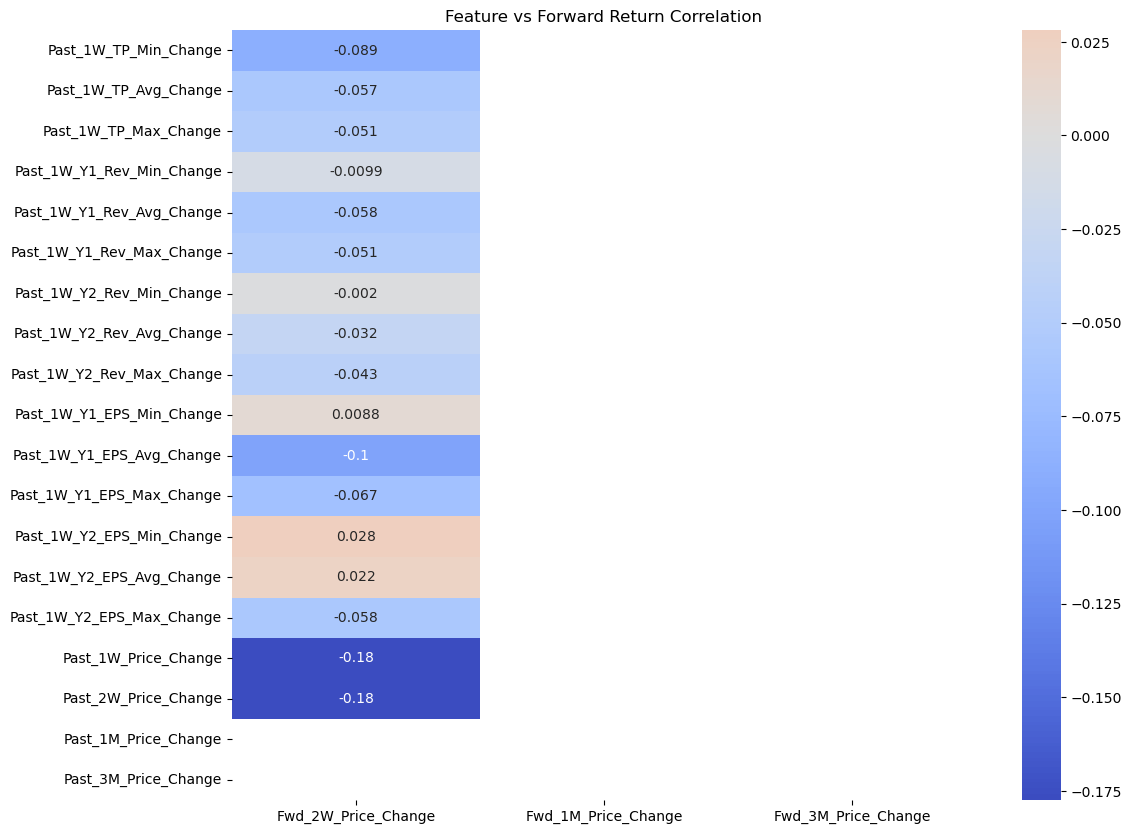

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load factor dataset
file = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus\20260206_YahooConsensus_FactorDataset.csv"
df = pd.read_csv(file, parse_dates=["Date"])

# Targets
targets = [
    "Fwd_2W_Price_Change",
    "Fwd_1M_Price_Change",
    "Fwd_3M_Price_Change",
]

# Features
features = [
    "Past_1W_TP_Min_Change", "Past_1W_TP_Avg_Change", "Past_1W_TP_Max_Change",
    "Past_1W_Y1_Rev_Min_Change", "Past_1W_Y1_Rev_Avg_Change", "Past_1W_Y1_Rev_Max_Change",
    "Past_1W_Y2_Rev_Min_Change", "Past_1W_Y2_Rev_Avg_Change", "Past_1W_Y2_Rev_Max_Change",
    "Past_1W_Y1_EPS_Min_Change", "Past_1W_Y1_EPS_Avg_Change", "Past_1W_Y1_EPS_Max_Change",
    "Past_1W_Y2_EPS_Min_Change", "Past_1W_Y2_EPS_Avg_Change", "Past_1W_Y2_EPS_Max_Change",
    "Past_1W_Price_Change", "Past_2W_Price_Change", "Past_1M_Price_Change", "Past_3M_Price_Change",
]

# Drop rows where all targets are NaN
df_corr = df.dropna(subset=targets, how="all")

# Compute correlation matrix
corr = df_corr[features + targets].corr()

# Extract feature ↔ target correlations
corr_with_targets = corr[targets].loc[features]

print("\n=== Correlation of Features with Forward Returns ===\n")
print(corr_with_targets.sort_values("Fwd_2W_Price_Change", ascending=False))

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_with_targets, annot=True, cmap="coolwarm", center=0)
plt.title("Feature vs Forward Return Correlation")
plt.show()

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
file = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus\20260206_YahooConsensus_FactorDataset.csv"
df = pd.read_csv(file, parse_dates=["Date"])

# Target
target = "Fwd_2W_Price_Change"

# Reduced feature set (more likely to have data)
features = [
    "Past_1W_TP_Avg_Change",
    "Past_1W_Y1_EPS_Avg_Change",
    "Past_1W_Y2_EPS_Avg_Change",
    "Past_1W_Price_Change"
]

# Keep rows where target exists
df_reg = df.dropna(subset=[target]).copy()

# Drop rows with NaNs in selected features
df_reg = df_reg.dropna(subset=features)

print("Rows available for regression:", len(df_reg))

if len(df_reg) < 30:
    print("Warning: Very small dataset. Regression results will be noisy.")

X = df_reg[features]
y = df_reg[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, random_state=42
)

# Lasso regression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

coef = pipe.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": features, "coef": coef})
coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index)

print("\n=== Lasso Coefficients ===\n")
print(coef_df)

Rows available for regression: 213
R2: -0.10065516233126082
RMSE: 0.0655593561038455

=== Lasso Coefficients ===

                     feature      coef
3       Past_1W_Price_Change -0.011272
1  Past_1W_Y1_EPS_Avg_Change -0.008830
2  Past_1W_Y2_EPS_Avg_Change  0.000494
0      Past_1W_TP_Avg_Change  0.000000


C:\Users\Sudhir Kulaye\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

